<a href="https://colab.research.google.com/github/cchan555/lis4693/blob/main/lab-3/ChanLab3Mar32026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
# Cody Chan
# Lab 3 Data Visualization using Altair

import altair as alt
import pandas as pd
import requests
import io

#
# Task 1: Using same 'Seattle Library Data', visualize atleast two different
# columns from the seattle_df dataframe
#
# Load in the dataset from GitHub
url = "https://raw.githubusercontent.com/manika-lamba/SP26-LIS4_5693/refs/heads/main/lab-assignments/lab-3/Seattle-Library_2015-2021.csv"
response = requests.get(url)
response.raise_for_status() # Raise exception for HTTP errors
# Convert downloaded text into readable dataframe
text = response.text
seattle_df = pd.read_csv(io.StringIO(text))
seattle_df # Display first few rows
# Group data by MaterialType and CheckedoutYear
seattle_material_grouped = seattle_df.groupby(
    ['MaterialType', 'CheckoutYear']).size().reset_index(name = 'counts')
# Provides visualization
chart1 = alt.Chart(seattle_material_grouped).mark_line().encode(
    x = alt.X('MaterialType', sort = '-y'),
    y = 'counts',
    color = 'CheckoutYear:N'
)
chart1

alt.Chart(...)

In [34]:
#
# Task 2: Use a different type of Altair mark for each visualization
# Note - Anything except vertical bar
#
# Utilize different mark type (area)
chart2 = alt.Chart(seattle_material_grouped).mark_area().encode(
    x = alt.X('MaterialType', sort = '-y'),
    y = 'counts',
    color = 'CheckoutYear:N'
)
chart2

alt.Chart(...)

In [33]:
#
# Task 3: Add interactivity to graph (panning zooming, tooltips,
# selection, binding, etc)
#
# Create selection that binds interaction to legend
selection = alt.selection_point(fields = ['CheckoutYear'], bind = 'legend')
# Update chart1 with Legend binding, Tooltip, opecity, and Zoom feature.
chart1 = alt.Chart(seattle_material_grouped).mark_line().encode(
    x = alt.X('MaterialType', sort = '-y'),
    y = 'counts',
    color = alt.Color('CheckoutYear:N',
                      sort = alt.EncodingSortField('CheckoutYear', order = 'descending')),
    # Display information when hovering
    tooltip = ['MaterialType', 'counts', 'CheckoutYear'],
    # Dim unselected legends
    opacity = alt.condition(selection, alt.value(1), alt.value(0.2))
).add_params(
    selection
).interactive() # Allows zooming
chart1


alt.Chart(...)

In [36]:
#
# Task 4: Create Horizontal Concatenation of both visualization side-by-side
#
chart1 | chart2 # | operation allows horizontal charts side by side

alt.HConcatChart(...)

Task 5: Reflection <br>
What went well? <br>
The instructions provided on Google Colab were helpful and very detailed. It allowed me to understand the concepts while seeing the examples. The example code was helpful because it showed me a potential method to use for my assignment, but it also allowed me to experiment with different methods if I wanted to explore them further.


What did not go well or what challenges you encountered? <br>
A challenge I encountered while doing this lab was creating the interactive plot. I recieved some errors while experimenting with the interactive plot like small typos and syntax errors. What helped me overcome this was going back to the examples provided in Google Colab. I was able to troubleshoot what was wrong with my code.

alt.Chart(...)

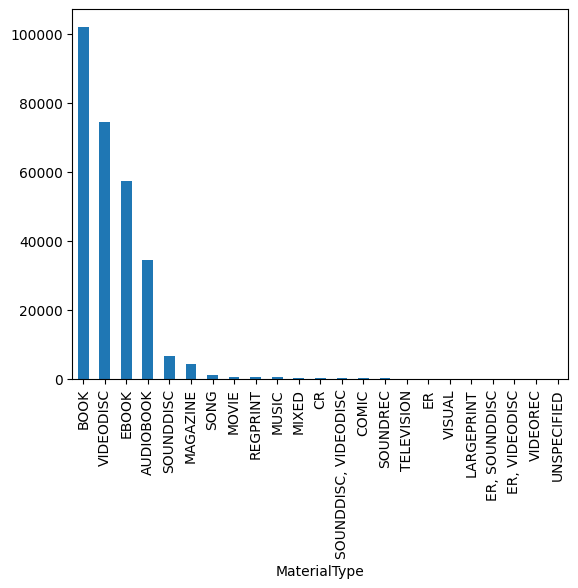

In [12]:
#
# Lecture Code w/ examples
#
import pandas as pd # Data manipulation
import altair as alt # Interaction visualization
from vega_datasets import data as vega_data

import requests
import io

# Load dataset from GitHub
url = "https://raw.githubusercontent.com/manika-lamba/SP26-LIS4_5693/refs/heads/main/lab-assignments/lab-3/Seattle-Library_2015-2021.csv"
response = requests.get(url)
response.raise_for_status() # Raise exception for HTTP errors
text = response.text

seattle_df = pd.read_csv(io.StringIO(text))
seattle_df.head()

# Pandas bar chart
seattle_df['MaterialType'].value_counts().plot(kind = 'bar')

# Simple dataframe
source = pd.DataFrame({
    'a': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I'],
    'b': [28, 55, 43, 91, 81, 53, 19, 87, 52]
})

# Simple Altair bar chart
alt.Chart(source).mark_bar().encode(
    x='a',
    y='b'
)

# Count values
seattle_df['MaterialType'].value_counts() # Count value

type(seattle_df['MaterialType'].value_counts()) # Check object type

# Convert series to dataframe for Altair
seattle_df['MaterialType'].value_counts().rename_axis('MaterialType').reset_index(name='counts')

# Example - Altair bar chart
source = seattle_df['MaterialType'].value_counts().rename_axis('MaterialType').reset_index(name='counts')
alt.Chart(source).mark_bar().encode(
    x='MaterialType',
    y='counts'
)

# Example - sorted bar chart
source = seattle_df['MaterialType'].value_counts().rename_axis('MaterialType').reset_index(name='counts')
alt.Chart(source).mark_bar().encode(
    x = alt.X('MaterialType', sort = '-y'),
    y = 'counts'
)

# Example - Vega dataset
cars = vega_data.cars()
cars.head()
alt.Chart(cars).mark_bar().encode(
    x = 'Horsepower',
    y = 'Miles_per_Gallon',
    color = 'Origin',
    shape = 'Origin'
)

# Example - Group by MaterialType and CheckoutYear
seattle_df
# Count how many checkout per material per year
seattle_material_grouped = seattle_df.groupby(['MaterialType', 'CheckoutYear']).size().reset_index(name = 'counts')
alt.Chart(seattle_material_grouped).mark_bar().encode( # Simple bar chart
    x = alt.X('MaterialType', sort = '-y'),
    y = 'counts',
    color = 'CheckoutYear:N'
)

# Example (with interactive)
alt.Chart(seattle_material_grouped).mark_bar().encode(
    x = alt.X('MaterialType', sort = '-y'),
    y = 'counts',
    color = 'CheckoutYear:N',
    tooltip = ['MaterialType', 'counts', 'CheckoutYear']
).interactive()

# Example (interactive w/ more features)
selection = alt.selection_point(fields = ['CheckoutYear'], bind = 'legend')
alt.Chart(seattle_material_grouped).mark_bar().encode(
    x = alt.X('MaterialType', sort = '-y'),
    y = 'counts',
    color = alt.Color('CheckoutYear:N', sort = alt.EncodingSortField('CheckoutYear', order = 'descending')),
    tooltip = ['MaterialType', 'counts', 'CheckoutYear'],
    opacity = alt.condition(selection, alt.value(1), alt.value(0.2)),
    order = 'CheckoutYear'
).add_params(
    selection
)